# 06 — Final comparison figures (Phase 7)

The last notebook. It reads all three metrics CSVs and the saved models, and
produces the publication figures in `plots/final/` (300 DPI, grayscale-safe).
No retraining — predictions for the ROC / confusion / importance charts are
recomputed by reloading saved models on the deterministic test split.

All chart logic lives in `src/evaluation/compare.py`; this notebook orchestrates.

In [1]:
import sys
from pathlib import Path

_cwd = Path.cwd()
REPO_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent
sys.path.insert(0, str(REPO_ROOT))

from IPython.display import Image, display
from src.evaluation import compare

metrics = compare.load_all_metrics()
print(f"{len(metrics)} model-dataset results "
      f"({(metrics.family=='classical').sum()} classical, {(metrics.family=='deep').sum()} deep)")

21 model-dataset results (18 classical, 3 deep)


## 1. Metric bars — accuracy / precision / recall / F1 per dataset

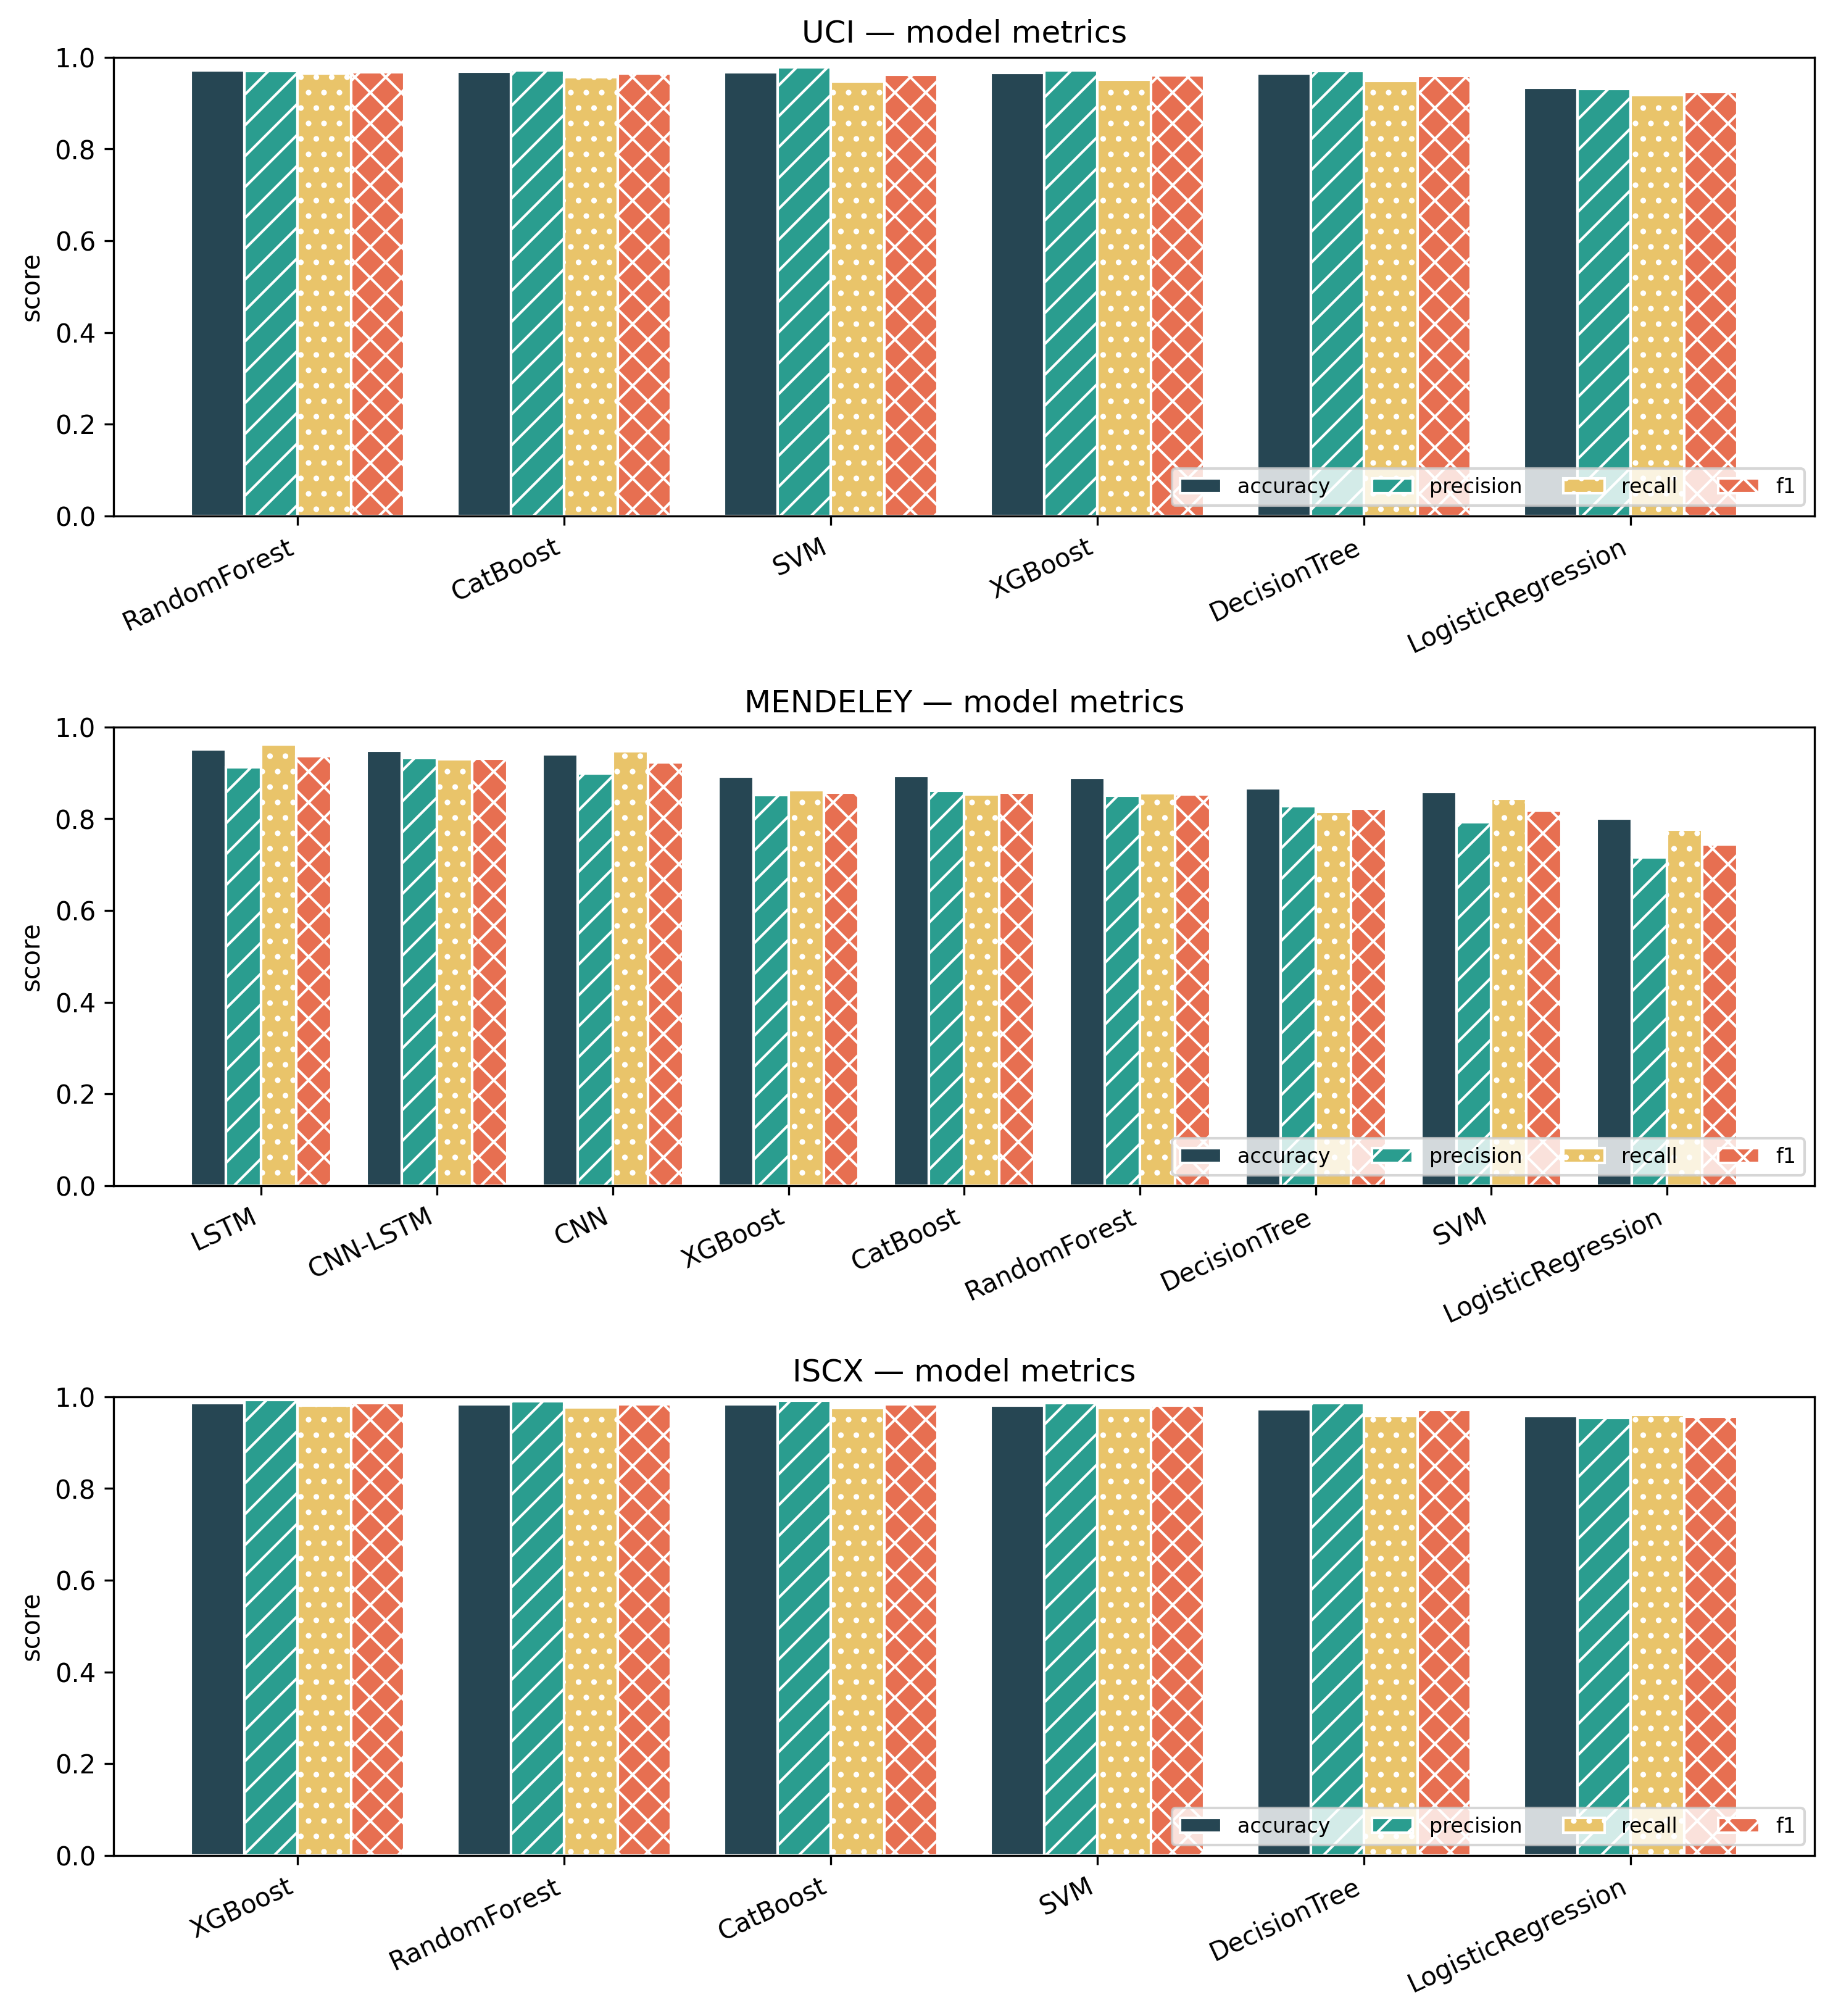

In [2]:
display(Image(filename=str(compare.fig_metric_bars(metrics))))

## 2. Overlaid ROC curves (per dataset, AUC in legend)

/home/otavio/Desktop/projetos/faculdade/phishing_detection/src/evaluation/compare.py:98: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path,

/home/otavio/Desktop/projetos/faculdade/phishing_detection/src/evaluation/compare.py:98: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path,

/home/otavio/Desktop/projetos/faculdade/phishing_detection/src/evaluation/compare.py:98: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path,

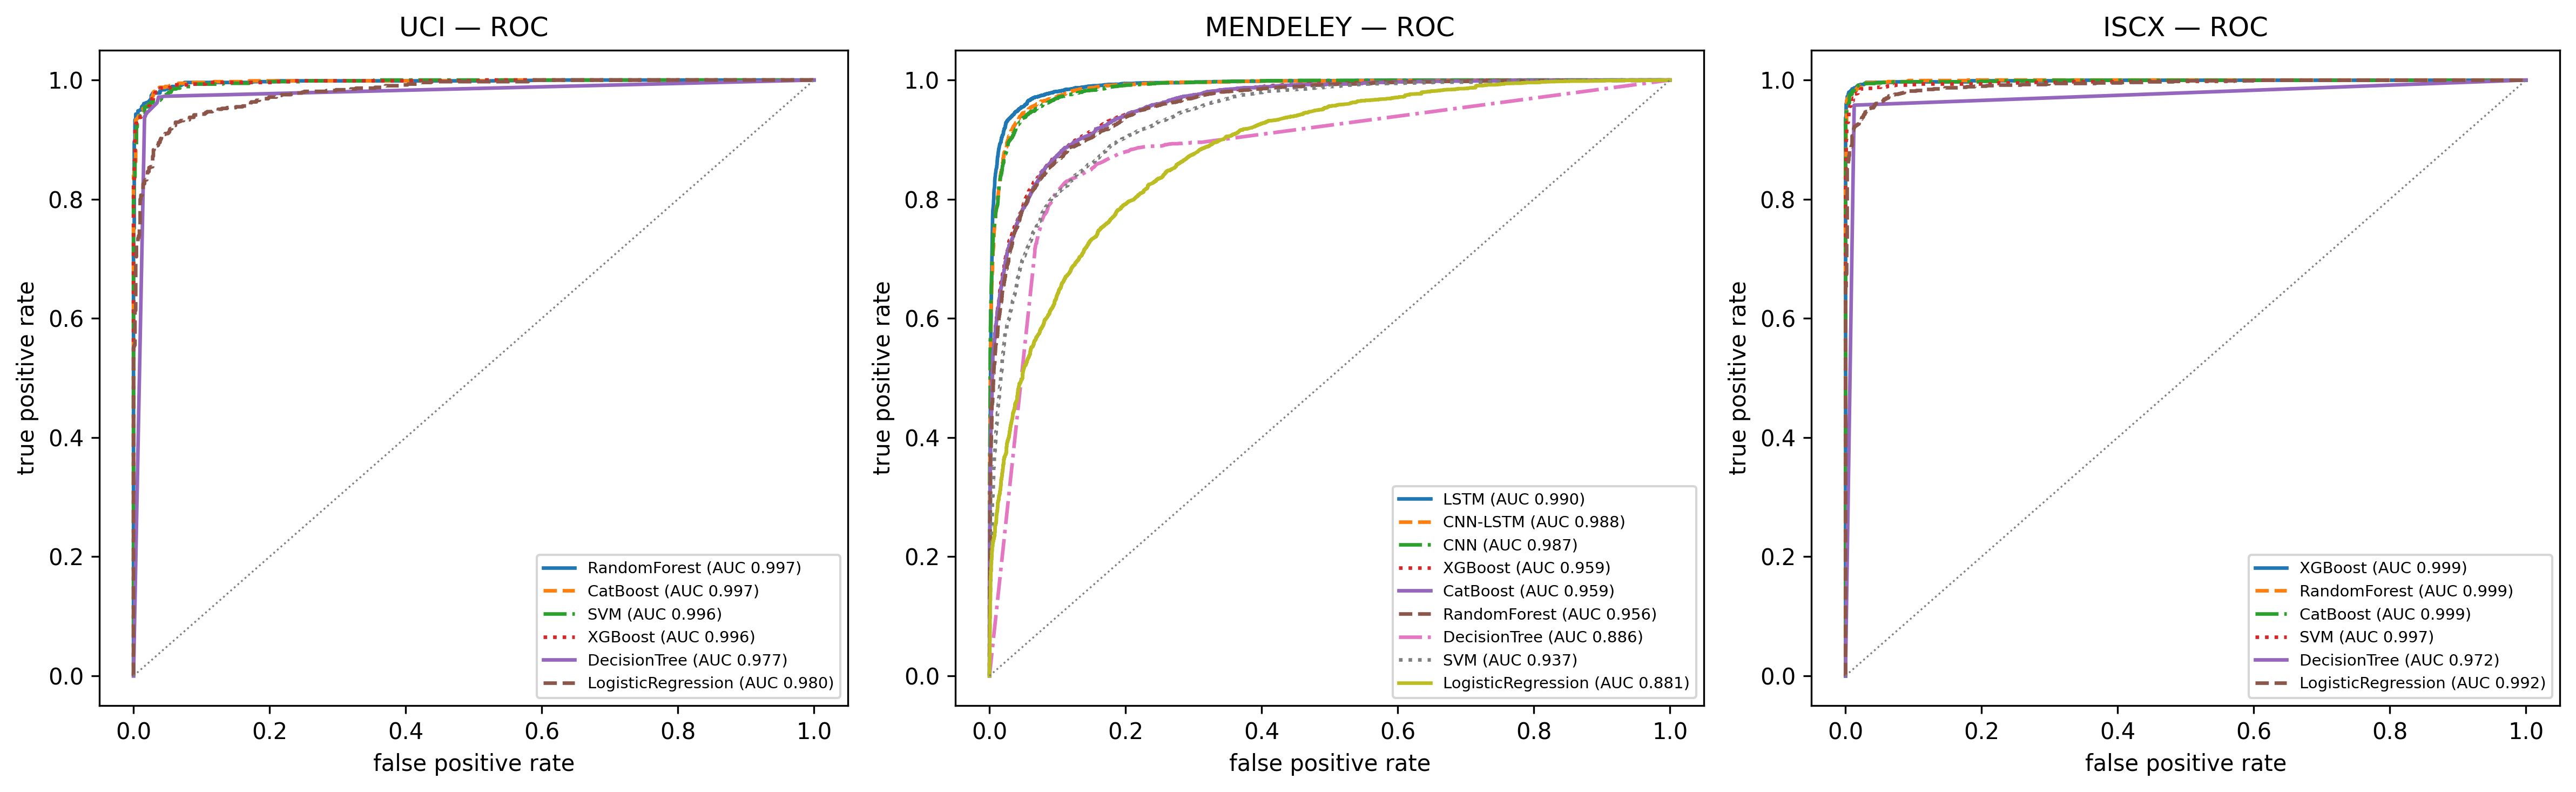

In [3]:
display(Image(filename=str(compare.fig_roc_overlay(metrics))))

## 3. F1 heatmap — models × datasets

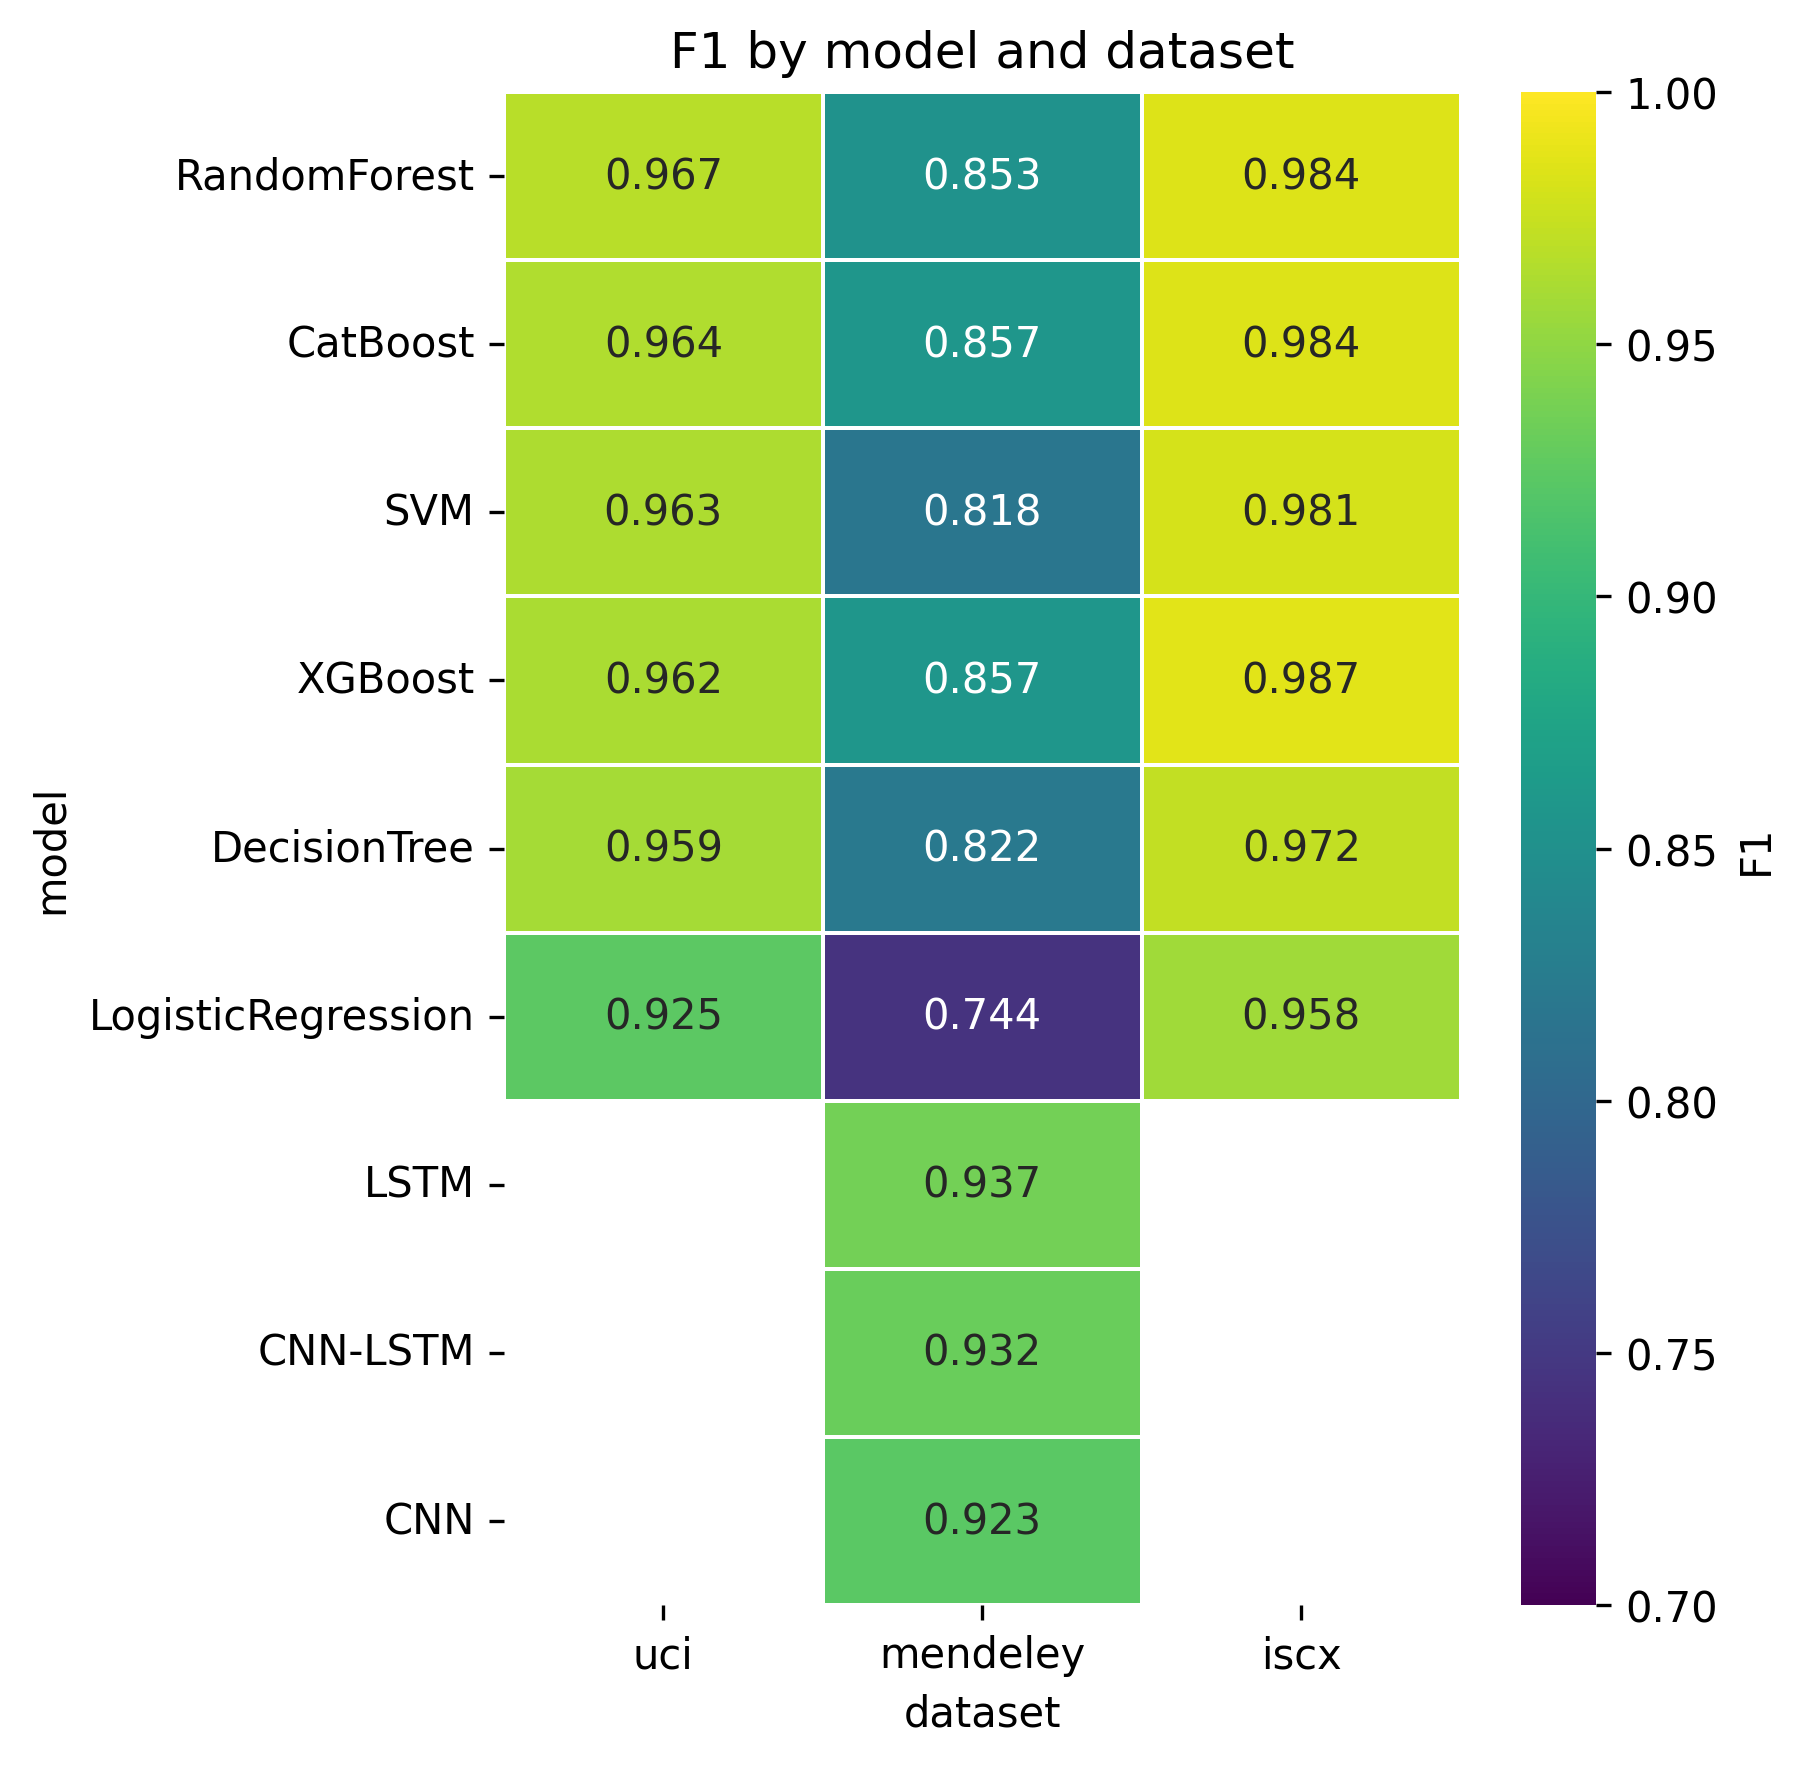

In [4]:
display(Image(filename=str(compare.fig_f1_heatmap(metrics))))

## 4. Confusion-matrix grid (Mendeley — all 9 models)

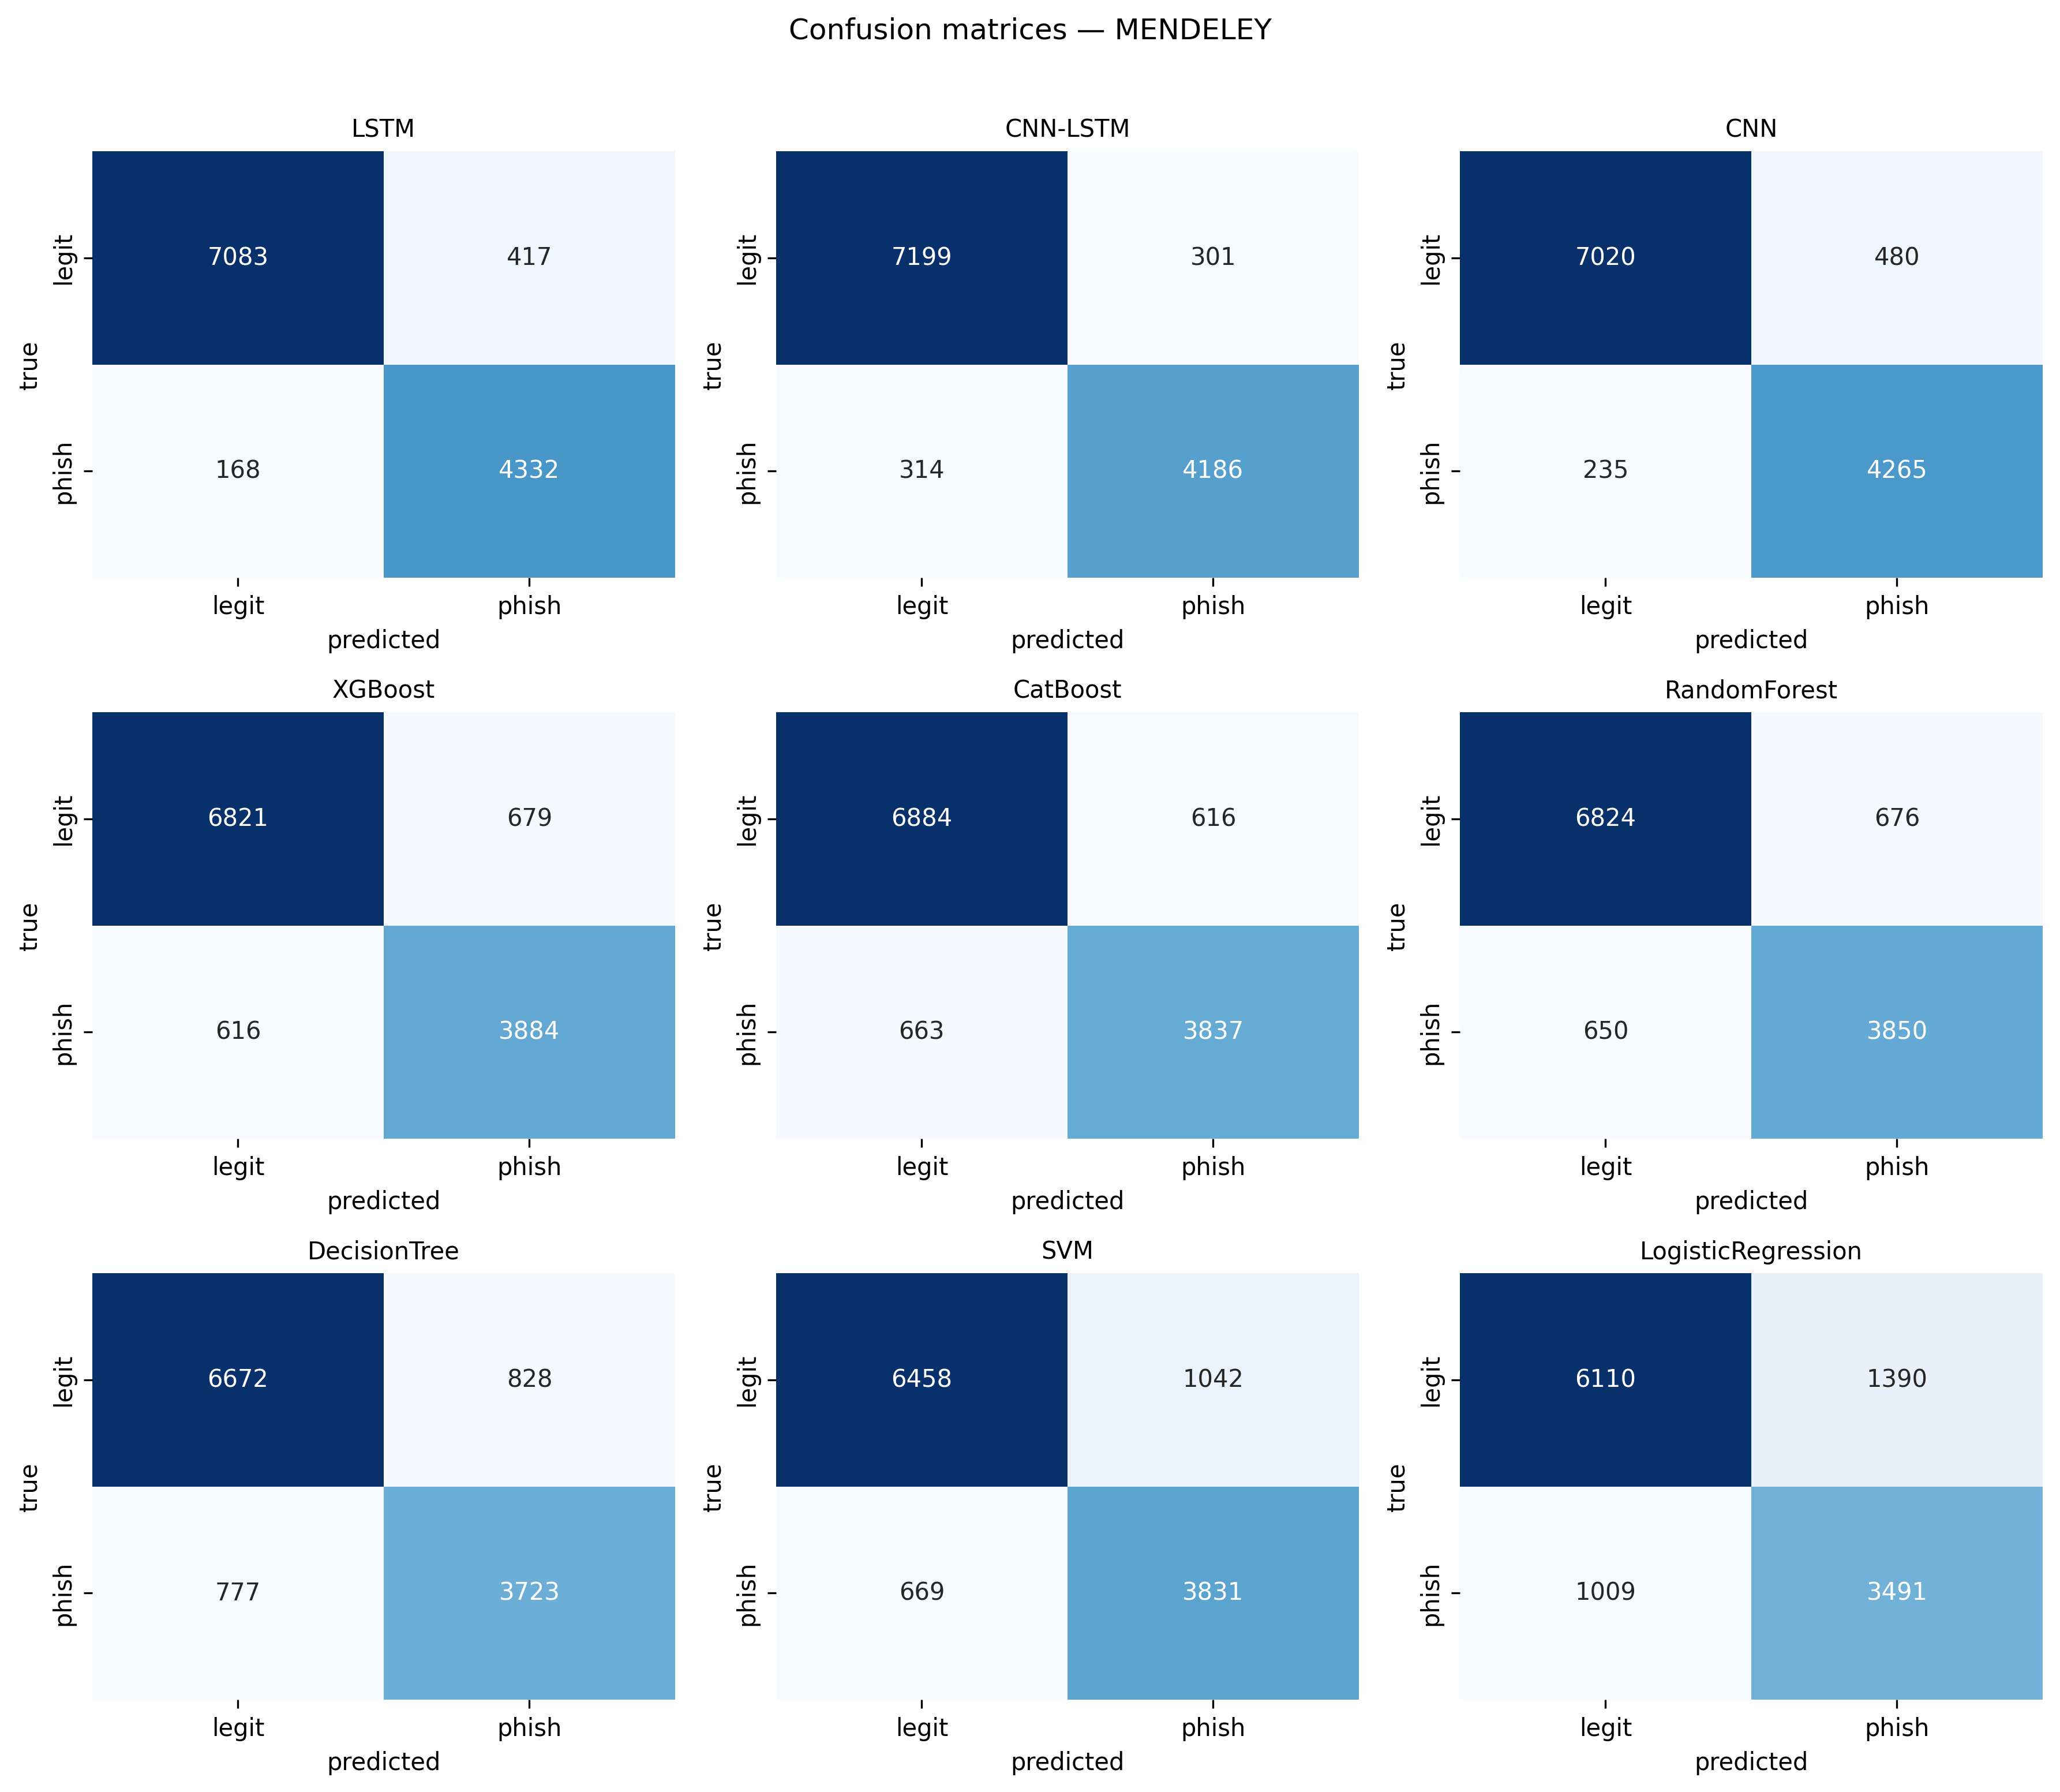

In [5]:
display(Image(filename=str(compare.fig_confusion_grid(metrics, 'mendeley'))))

## 5. Training cost vs F1

Fast **and** accurate models sit upper-left.

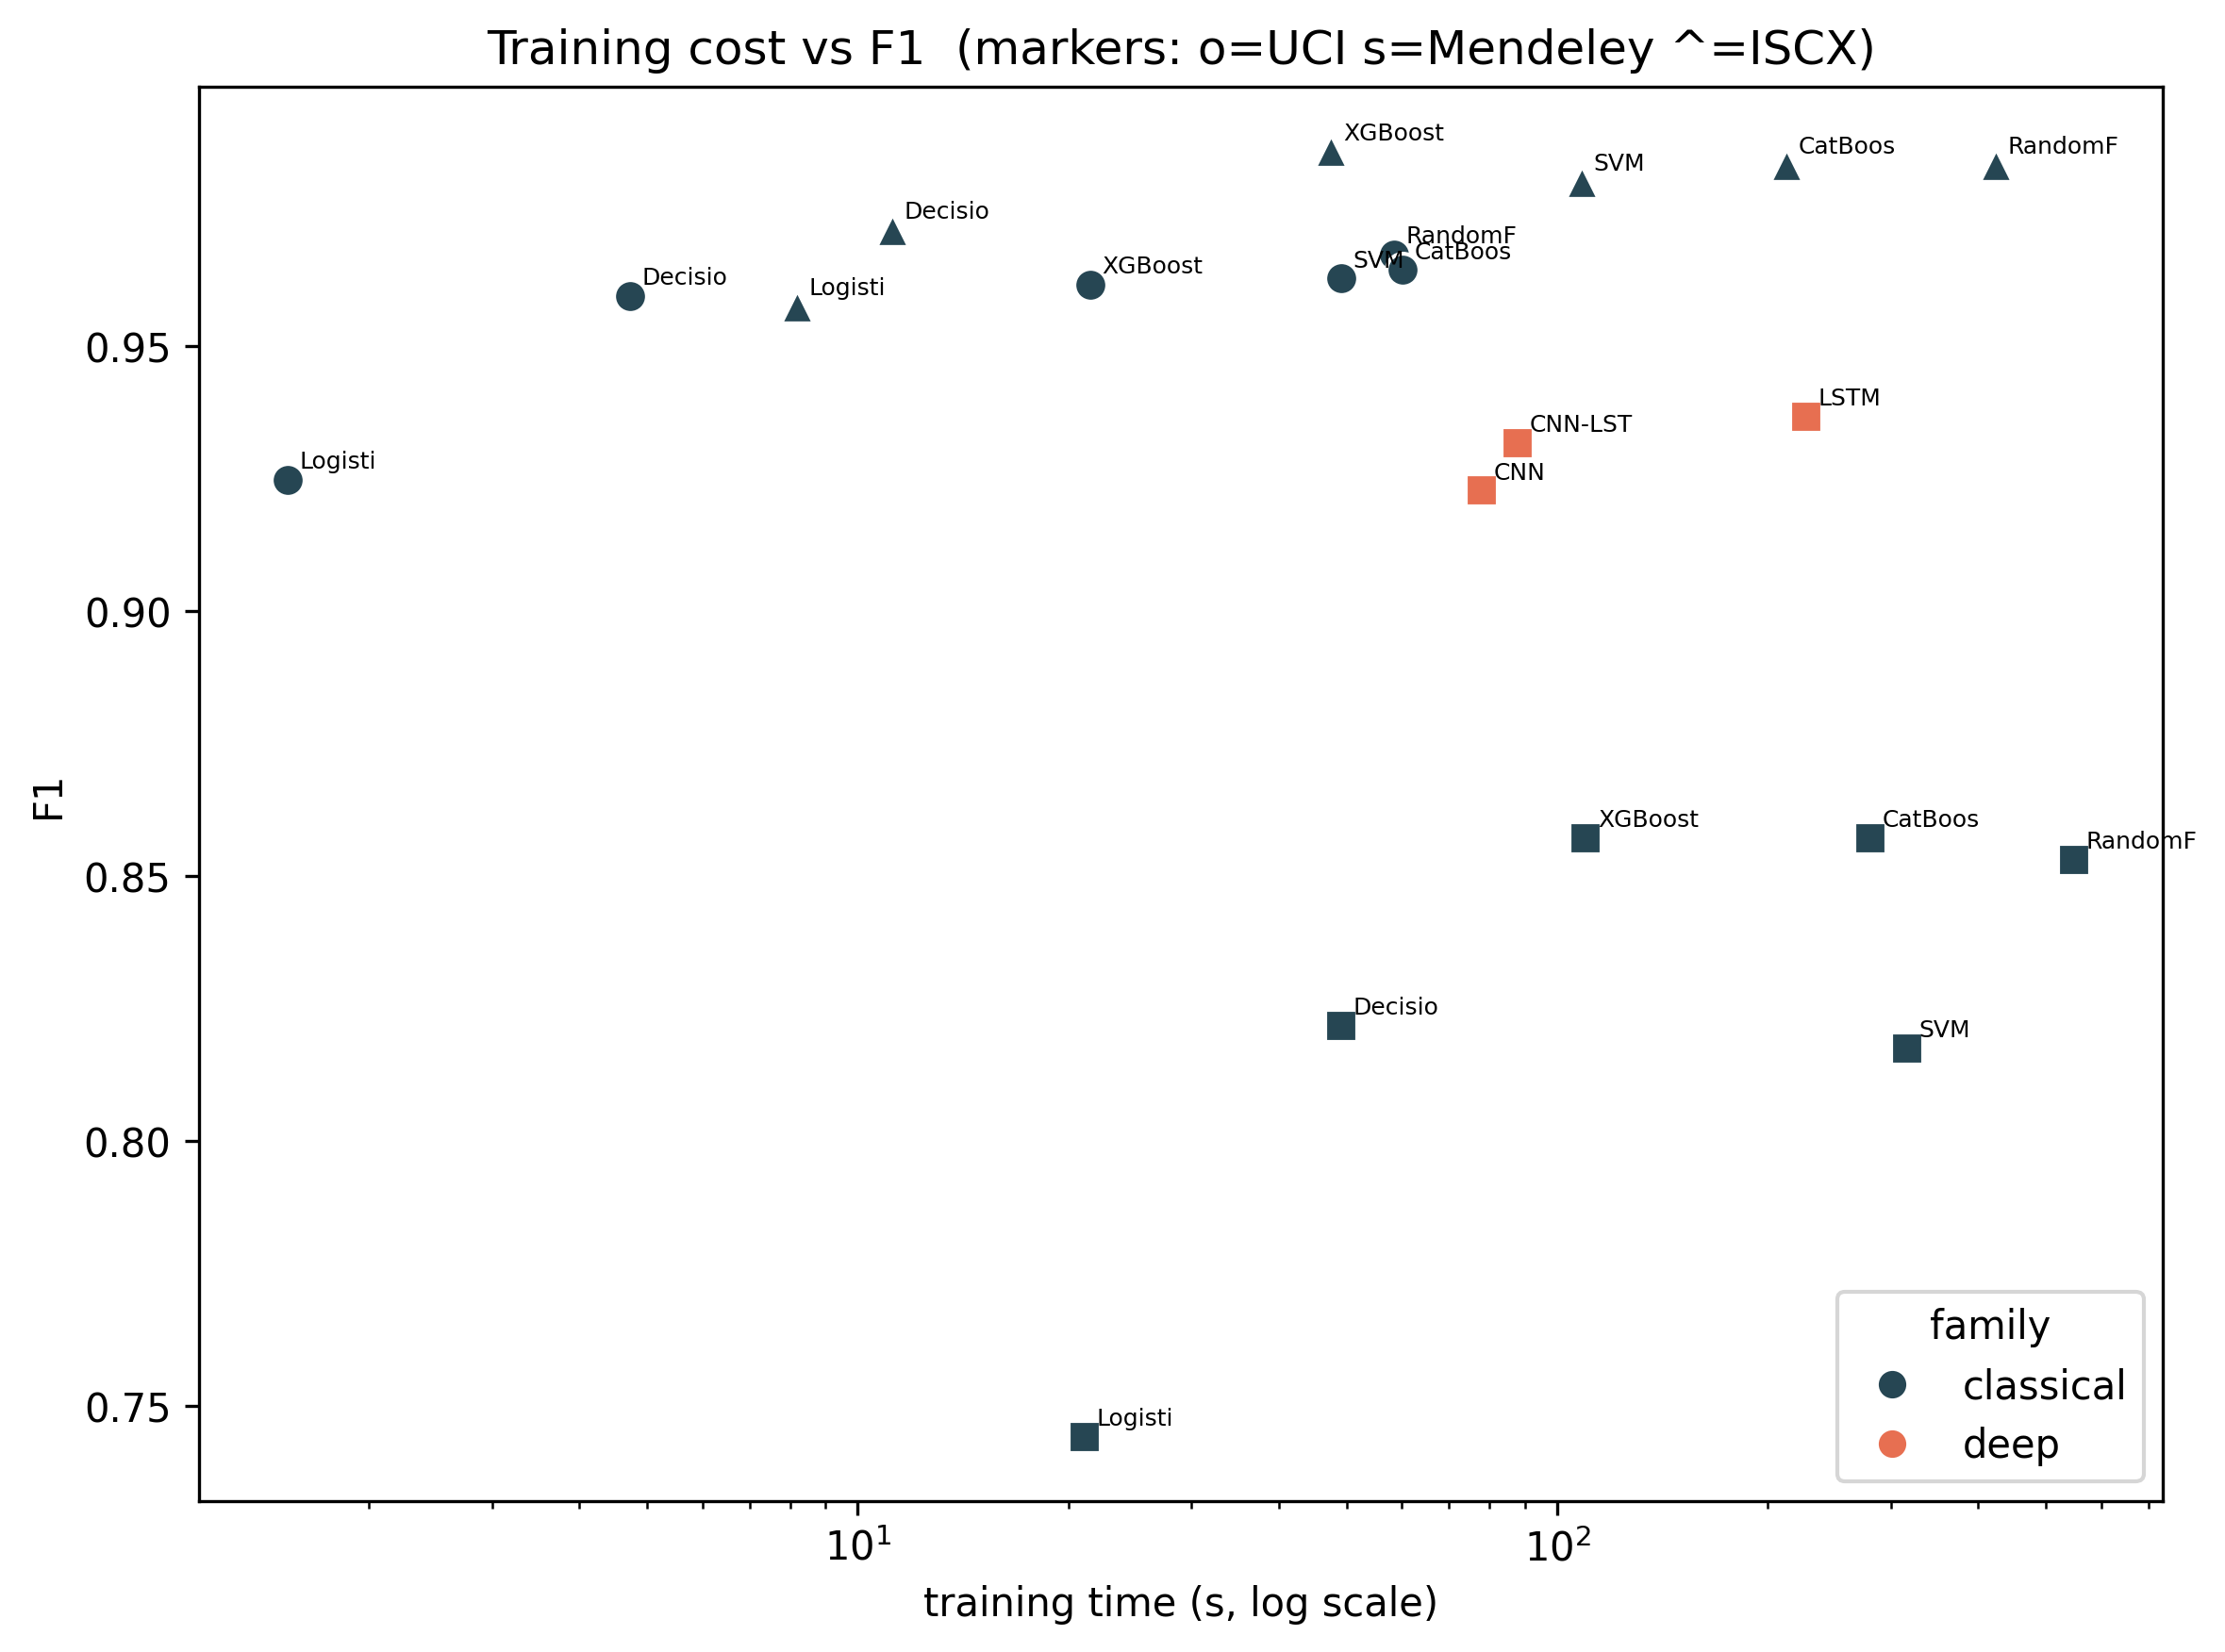

In [6]:
display(Image(filename=str(compare.fig_time_vs_f1(metrics))))

## 6. Feature importance — RandomForest vs XGBoost (UCI)

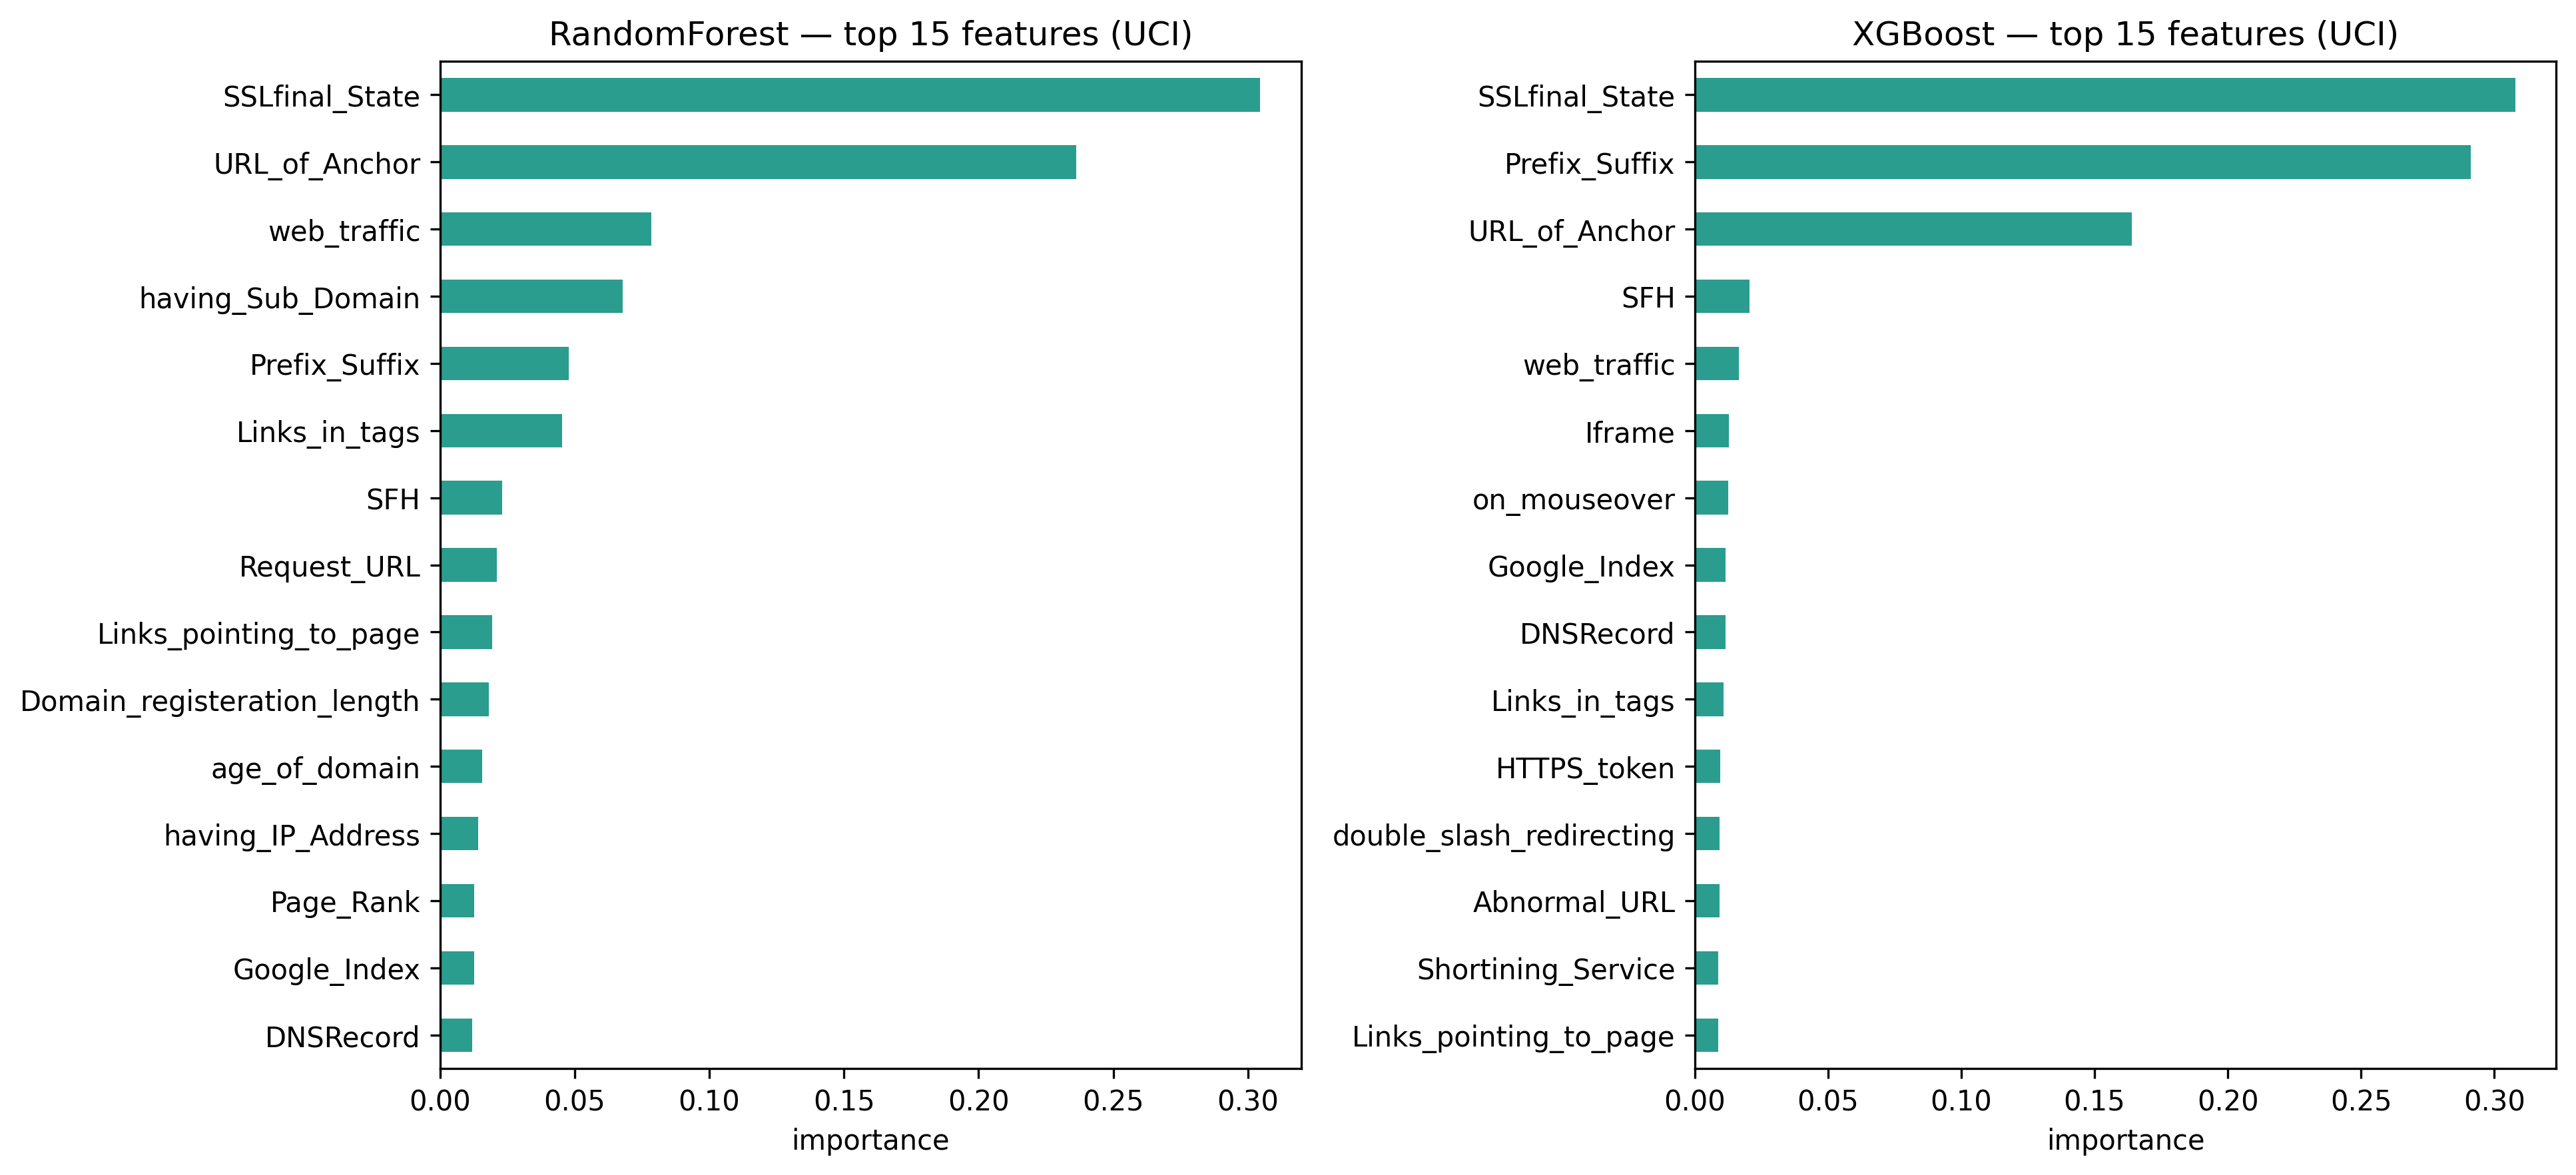

In [7]:
display(Image(filename=str(compare.fig_feature_importance('uci'))))

## 7. Generalization gap (the key finding)

Within-dataset vs cross-dataset F1 — every model collapses on an unseen dataset,
revealing that high within-dataset scores are largely dataset memorization.

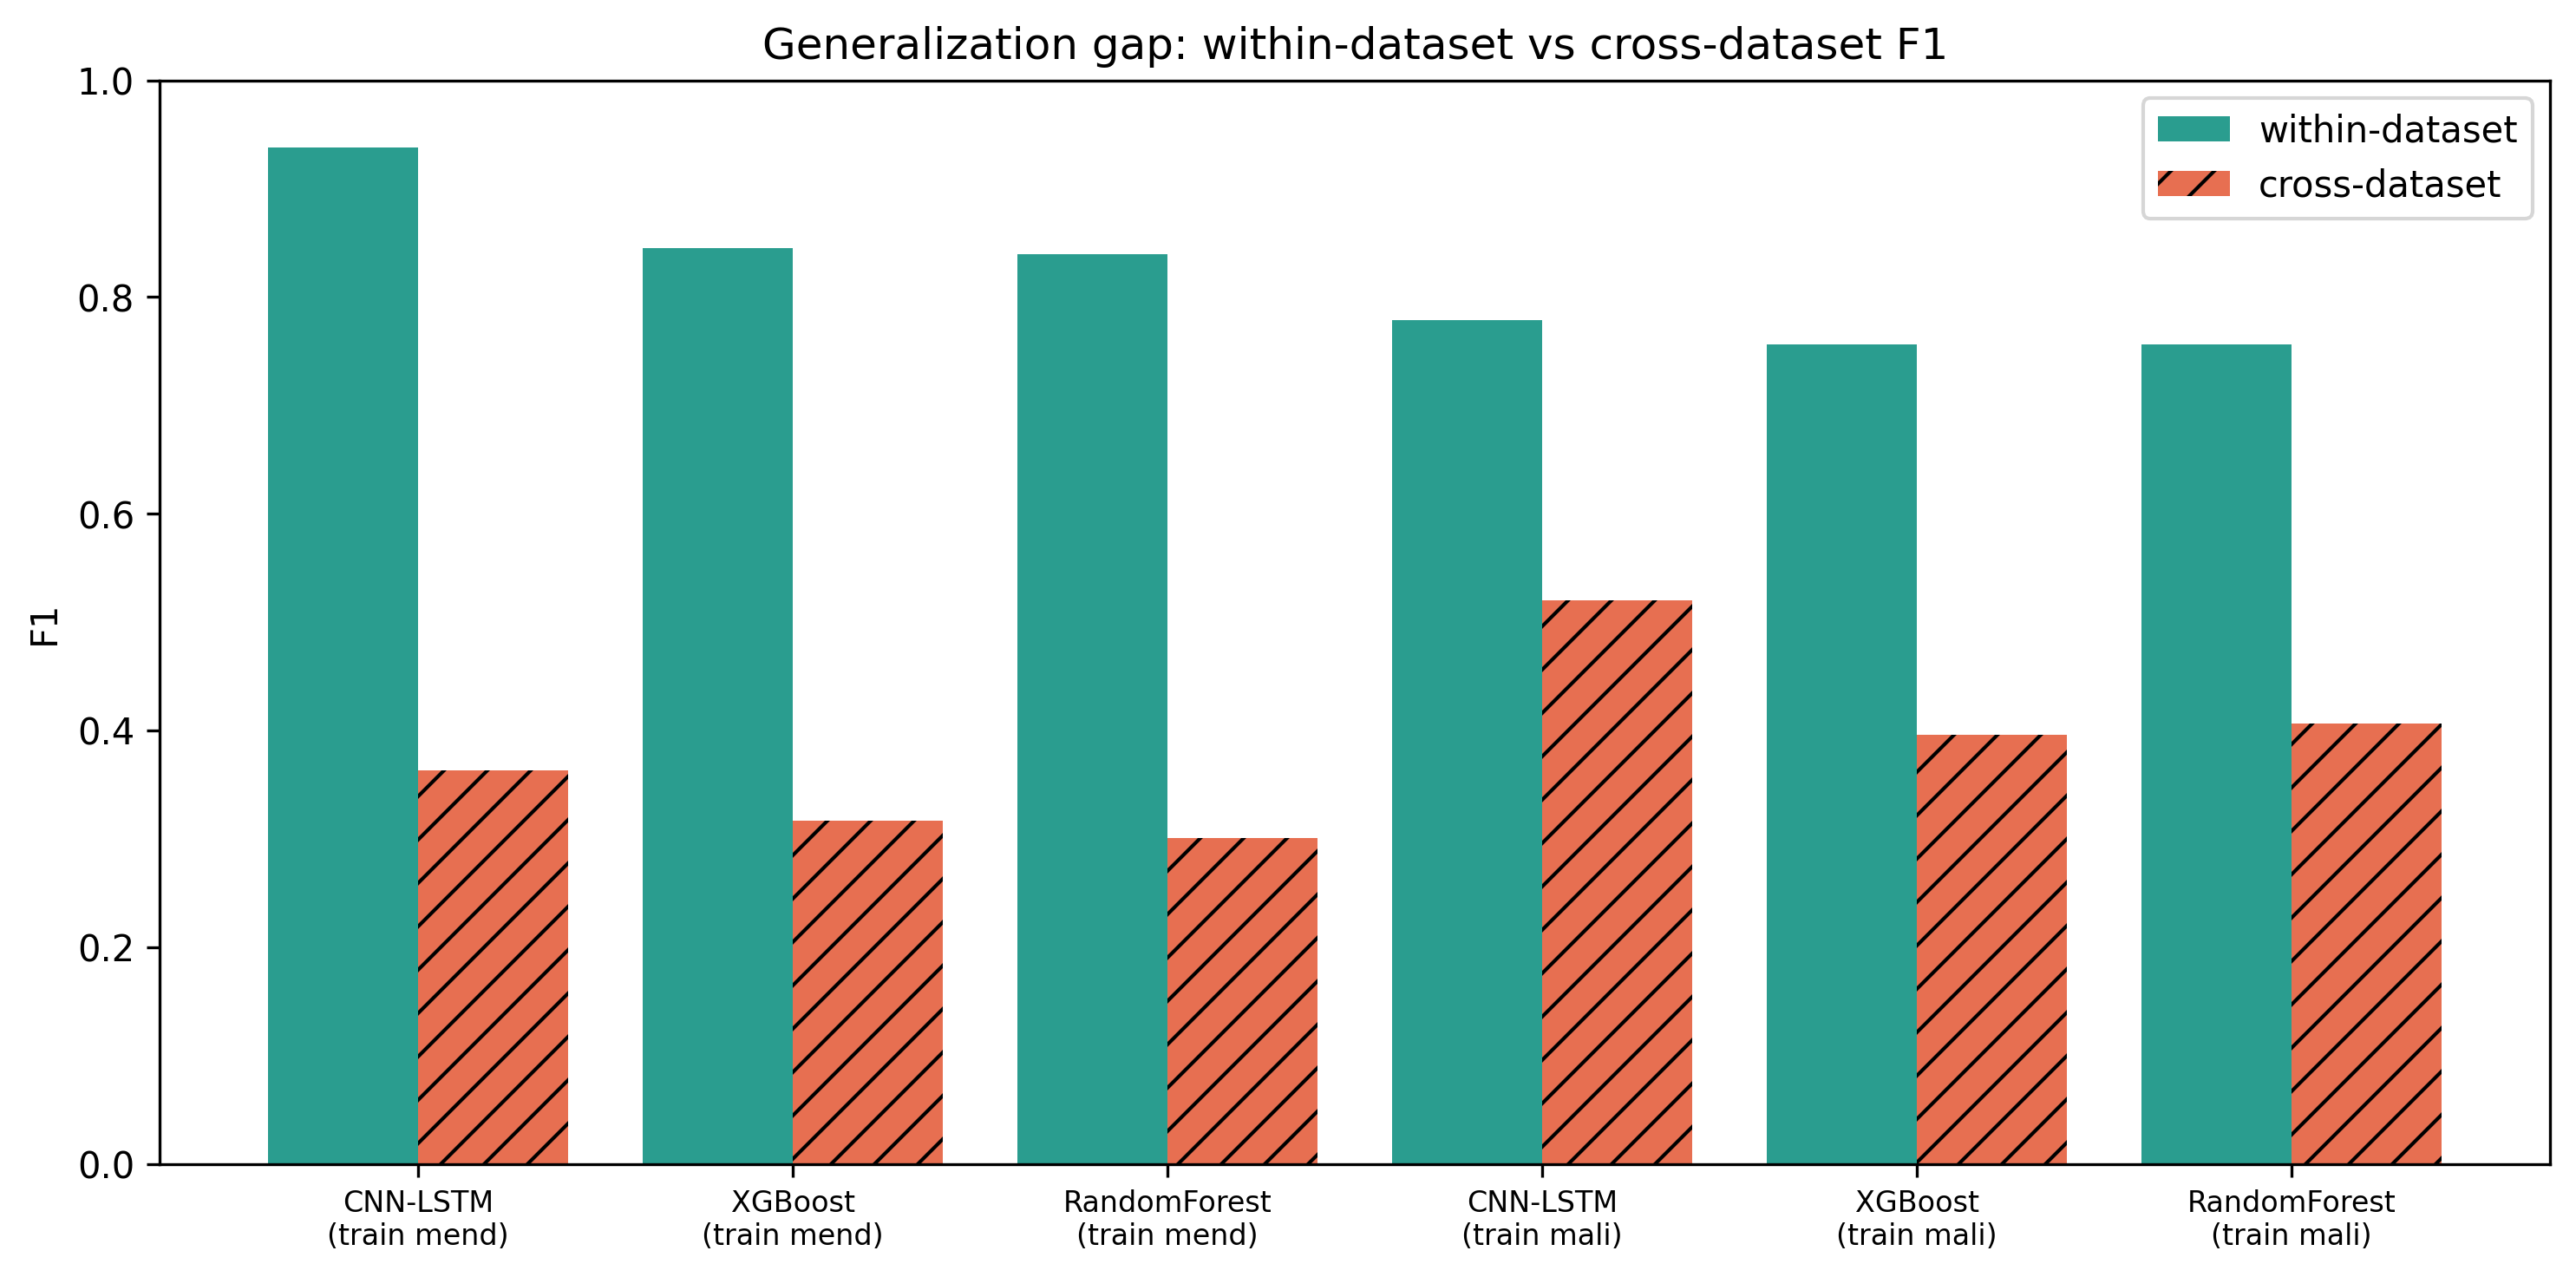

In [8]:
display(Image(filename=str(compare.fig_crossdataset_drop())))

## Done — experimental stage complete

All seven figures are in `plots/final/` at 300 DPI, ready for the dissertation.
Phases 0–7 are complete (Phase 5 / DistilBERT skipped, D-009).